# Controlled Fine-Tuning of MobileNetV2

This notebook continues from the best frozen-backbone transfer-learning checkpoint. It fine-tunes only the final MobileNetV2 layers with a very low learning rate. Model selection uses the validation split; the reserved test split is never loaded into a TensorFlow dataset or evaluated here.

## Experimental protocol

- **Smoke:** 64 training images, 32 validation images, 1 epoch.
- **Standard:** all training and validation images, at most 12 epochs.
- Unfreeze the last 20 backbone layers while keeping all BatchNormalization layers frozen.
- Adam optimizer with learning rate `1e-5`.
- Training-only augmentation and class weights are retained.
- Early stopping and checkpointing monitor validation loss.

> Set `RUN_MODE` only after the smoke run succeeds and its runtime has been reviewed.

In [1]:
from __future__ import annotations
import json, os, random, time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
RUN_MODE = 'standard'  # Approved after the successful smoke run.
UNFREEZE_LAST_N = 20
FINE_TUNE_LR = 1e-5
PROJECT_ROOT = Path.cwd().resolve()
MANIFEST_PATH = PROJECT_ROOT / 'data/processed/tile/manifests/tile_supervised_splits.csv'
SOURCE_MODEL_PATH = PROJECT_ROOT / 'outputs/models/milestone2/mobilenetv2_transfer_best.keras'
MODEL_DIR = PROJECT_ROOT / 'outputs/models/milestone4'
HISTORY_DIR = PROJECT_ROOT / 'outputs/histories/milestone4'
FIGURE_DIR = PROJECT_ROOT / 'outputs/figures/milestone4'
for directory in (MODEL_DIR, HISTORY_DIR, FIGURE_DIR): directory.mkdir(parents=True, exist_ok=True)
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)
print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))
print('Run mode:', RUN_MODE)

TensorFlow: 2.21.0
GPUs: []
Run mode: standard


In [2]:
MODE_CONFIG = {
    'smoke': {'train_limit': 64, 'validation_limit': 32, 'epochs': 1},
    'standard': {'train_limit': None, 'validation_limit': None, 'epochs': 12},
}
config = MODE_CONFIG[RUN_MODE]
manifest = pd.read_csv(MANIFEST_PATH)
required = {'source_path','relative_path','binary_class','binary_label','split','group_id','sha256'}
assert required.issubset(manifest.columns)
assert manifest.groupby('group_id')['split'].nunique().max() == 1
assert manifest.groupby('sha256')['split'].nunique().max() == 1
train_frame = manifest.loc[manifest['split'].eq('train')].copy()
validation_frame = manifest.loc[manifest['split'].eq('validation')].copy()
reserved_test_count = int(manifest['split'].eq('test').sum())

def stratified_limit(frame, limit, seed):
    if limit is None or limit >= len(frame):
        return frame.sample(frac=1, random_state=seed).reset_index(drop=True)
    parts = []
    counts = frame['binary_label'].value_counts(normalize=True)
    remaining = limit
    for pos, label in enumerate(sorted(counts.index)):
        n = remaining if pos == len(counts)-1 else max(1, round(limit * counts[label]))
        remaining -= n
        subset = frame.loc[frame['binary_label'].eq(label)]
        parts.append(subset.sample(n=min(n, len(subset)), random_state=seed+int(label)))
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

active_train = stratified_limit(train_frame, config['train_limit'], SEED)
active_validation = stratified_limit(validation_frame, config['validation_limit'], SEED+10)
print('Train:', len(active_train), active_train['binary_class'].value_counts().to_dict())
print('Validation:', len(active_validation), active_validation['binary_class'].value_counts().to_dict())
print('Reserved test images (not evaluated):', reserved_test_count)

Train: 242 {'good': 184, 'defective': 58}
Validation: 54 {'good': 40, 'defective': 14}
Reserved test images (not evaluated): 51


In [3]:
AUTOTUNE = tf.data.AUTOTUNE
def decode_resize(path, label):
    image = tf.io.decode_png(tf.io.read_file(path), channels=3)
    image = tf.cast(tf.image.resize(image, IMAGE_SIZE, antialias=True), tf.float32)
    return image, tf.cast(label, tf.float32)
def make_dataset(frame, training):
    ds = tf.data.Dataset.from_tensor_slices((frame['source_path'].astype(str).to_numpy(), frame['binary_label'].astype(np.float32).to_numpy()))
    if training: ds = ds.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    return ds.map(decode_resize, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
train_dataset = make_dataset(active_train, True)
validation_dataset = make_dataset(active_validation, False)
train_counts = train_frame['binary_label'].value_counts().sort_index()
class_weights = {int(k): float(len(train_frame)/(len(train_counts)*v)) for k,v in train_counts.items()}
print('Class weights:', class_weights)

Class weights: {0: 0.657608695652174, 1: 2.086206896551724}


In [4]:
def classification_metrics():
    return [tf.keras.metrics.BinaryAccuracy(name='accuracy'), tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='roc_auc'), tf.keras.metrics.AUC(curve='PR', name='pr_auc')]

model = tf.keras.models.load_model(SOURCE_MODEL_PATH, compile=False)
backbone = next(layer for layer in model.layers if isinstance(layer, tf.keras.Model) and 'mobilenetv2' in layer.name)
backbone.trainable = True
for layer in backbone.layers[:-UNFREEZE_LAST_N]: layer.trainable = False
for layer in backbone.layers[-UNFREEZE_LAST_N:]:
    layer.trainable = not isinstance(layer, tf.keras.layers.BatchNormalization)
model.compile(optimizer=tf.keras.optimizers.Adam(FINE_TUNE_LR), loss=tf.keras.losses.BinaryCrossentropy(), metrics=classification_metrics())
trainable_backbone = [layer.name for layer in backbone.layers if layer.trainable]
print('Trainable backbone layers:', trainable_backbone)
print(f'Trainable parameters: {sum(np.prod(v.shape) for v in model.trainable_weights):,}')
print(f'Non-trainable parameters: {sum(np.prod(v.shape) for v in model.non_trainable_weights):,}')

Trainable backbone layers: ['block_15_expand', 'block_15_expand_relu', 'block_15_depthwise', 'block_15_depthwise_relu', 'block_15_project', 'block_15_add', 'block_16_expand', 'block_16_expand_relu', 'block_16_depthwise', 'block_16_depthwise_relu', 'block_16_project', 'Conv_1', 'out_relu']
Trainable parameters: 1,196,161
Non-trainable parameters: 1,063,104


In [5]:
run_name = f'mobilenetv2_finetuned_{RUN_MODE}'
checkpoint_path = MODEL_DIR / f'{run_name}_best.keras'
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.TerminateOnNaN(),
]
start = time.perf_counter()
history = model.fit(train_dataset, validation_data=validation_dataset, epochs=config['epochs'], class_weight=class_weights, callbacks=callbacks, verbose=2)
runtime_seconds = time.perf_counter() - start
history_frame = pd.DataFrame(history.history)
history_frame.index += 1; history_frame.index.name = 'epoch'
history_frame.to_csv(HISTORY_DIR / f'{run_name}_history.csv')
print(f'Runtime: {runtime_seconds:.2f} seconds ({runtime_seconds/60:.2f} minutes)')
display(history_frame)

Epoch 1/12

Epoch 1: val_loss improved from None to 0.22244, saving model to D:\Final Project\outputs\models\milestone4\mobilenetv2_finetuned_standard_best.keras
16/16 - 42s - 3s/step - accuracy: 0.8802 - loss: 0.3870 - pr_auc: 0.8444 - precision: 0.7458 - recall: 0.7586 - roc_auc: 0.8948 - val_accuracy: 0.9259 - val_loss: 0.2224 - val_pr_auc: 0.9347 - val_precision: 0.8571 - val_recall: 0.8571 - val_roc_auc: 0.9732 - learning_rate: 1.0000e-05
Epoch 2/12

Epoch 2: val_loss improved from 0.22244 to 0.17881, saving model to D:\Final Project\outputs\models\milestone4\mobilenetv2_finetuned_standard_best.keras
16/16 - 13s - 804ms/step - accuracy: 0.9008 - loss: 0.2977 - pr_auc: 0.9088 - precision: 0.7656 - recall: 0.8448 - roc_auc: 0.9363 - val_accuracy: 0.9259 - val_loss: 0.1788 - val_pr_auc: 0.9514 - val_precision: 0.9167 - val_recall: 0.7857 - val_roc_auc: 0.9804 - learning_rate: 1.0000e-05
Epoch 3/12

Epoch 3: val_loss did not improve from 0.17881
16/16 - 11s - 701ms/step - accuracy: 0.

,accuracy,loss,pr_auc,precision,recall,roc_auc,val_accuracy,val_loss,val_pr_auc,val_precision,val_recall,val_roc_auc,learning_rate
epoch,,,,,,,,,,,,,
1,0.880165,0.387032,0.844414,0.745763,0.758621,0.894771,0.925926,0.222435,0.934732,0.857143,0.857143,0.973214,0.000010
2,0.900826,0.297679,0.908754,0.765625,0.844828,0.936282,0.925926,0.178811,0.951359,0.916667,0.785714,0.980357,0.000010
3,0.921488,0.290170,0.912189,0.882353,0.775862,0.954179,0.925926,0.257416,0.961962,0.812500,0.928571,0.985714,0.000010
4,0.867769,0.274831,0.906298,0.675676,0.862069,0.954132,0.944444,0.146232,0.971436,0.923077,0.857143,0.989286,0.000010
5,0.917355,0.260336,0.919489,0.787879,0.896552,0.964018,0.944444,0.137723,0.971436,0.923077,0.857143,0.989286,0.000010
6,0.950413,0.293787,0.926884,0.960000,0.827586,0.954085,0.888889,0.349582,0.951359,0.700000,1.000000,0.980357,0.000010
7,0.896694,0.245590,0.932568,0.739130,0.879310,0.957552,0.944444,0.140615,0.970346,0.923077,0.857143,0.988393,0.000010
8,0.958678,0.224234,0.948403,0.961538,0.862069,0.962940,0.944444,0.153219,0.972658,0.866667,0.928571,0.989286,0.000002
9,0.942149,0.223632,0.945511,0.854839,0.913793,0.962144,0.944444,0.165845,0.972658,0.866667,0.928571,0.989286,0.000002


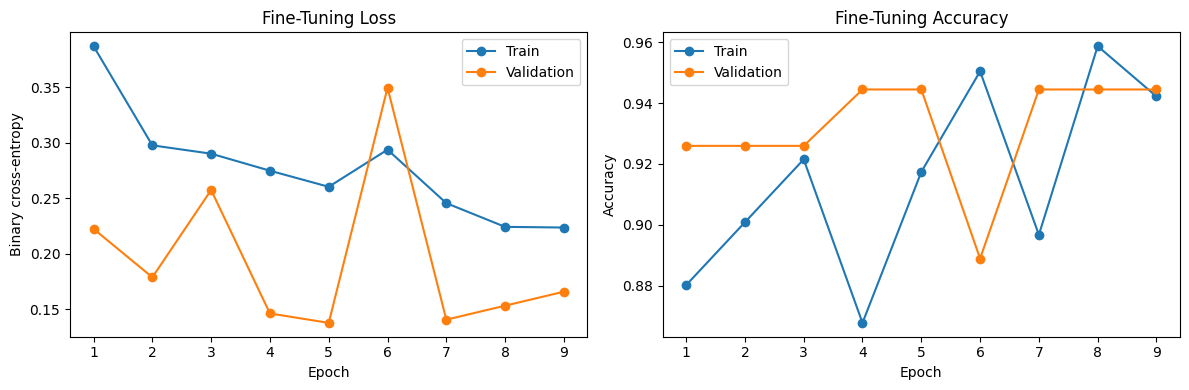

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_frame.index, history_frame['loss'], marker='o', label='Train'); axes[0].plot(history_frame.index, history_frame['val_loss'], marker='o', label='Validation'); axes[0].set(title='Fine-Tuning Loss', xlabel='Epoch', ylabel='Binary cross-entropy'); axes[0].legend()
axes[1].plot(history_frame.index, history_frame['accuracy'], marker='o', label='Train'); axes[1].plot(history_frame.index, history_frame['val_accuracy'], marker='o', label='Validation'); axes[1].set(title='Fine-Tuning Accuracy', xlabel='Epoch', ylabel='Accuracy'); axes[1].legend()
fig.tight_layout(); fig.savefig(FIGURE_DIR / f'{run_name}_learning_curves.png', dpi=160, bbox_inches='tight'); plt.show()

In [7]:
best_epoch = int(history_frame['val_loss'].idxmin())
summary = {'run_mode': RUN_MODE, 'source_model': SOURCE_MODEL_PATH.name, 'unfreeze_last_n': UNFREEZE_LAST_N, 'fine_tune_learning_rate': FINE_TUNE_LR, 'epochs_completed': len(history_frame), 'best_epoch': best_epoch, 'runtime_seconds': runtime_seconds, 'train_images': len(active_train), 'validation_images': len(active_validation), 'reserved_test_images': reserved_test_count, 'test_evaluated': False, 'best_validation_metrics': {key: float(history_frame.loc[best_epoch, key]) for key in history_frame.columns if key.startswith('val_')}}
summary_path = HISTORY_DIR / f'{run_name}_summary.json'
summary_path.write_text(json.dumps(summary, indent=2), encoding='utf-8')
print(json.dumps(summary, indent=2))

{
  "run_mode": "standard",
  "source_model": "mobilenetv2_transfer_best.keras",
  "unfreeze_last_n": 20,
  "fine_tune_learning_rate": 1e-05,
  "epochs_completed": 9,
  "best_epoch": 5,
  "runtime_seconds": 145.94541510008276,
  "train_images": 242,
  "validation_images": 54,
  "reserved_test_images": 51,
  "test_evaluated": false,
  "best_validation_metrics": {
    "val_accuracy": 0.9444444179534912,
    "val_loss": 0.13772279024124146,
    "val_pr_auc": 0.971435546875,
    "val_precision": 0.9230769276618958,
    "val_recall": 0.8571428656578064,
    "val_roc_auc": 0.9892857074737549
  }
}


## Interpretation guardrails

The smoke run verifies code and runtime only; it is not evidence of final model quality. The Standard run may be compared with the frozen-backbone model on the identical validation split. Thresholds must then be recalibrated using validation predictions. The test set remains reserved for a single final evaluation after the model and thresholds are fixed.